# K-Means-segmentatie van abonneegedrag met PROC FASTCLUS


## Samenvatting

Deze notebook segmenteert een synthetisch bestand van 100 mobiele abonnees in gedragsclusters met `PROC FASTCLUS`, de k-means-clusterprocedure van Base SAS. Zeven gebruiksvariabelen worden gestandaardiseerd naar z-scores met `PROC STDIZE`, zodat variabelen met grote schaal (spraakminuten, sms-aantallen) de Euclidische afstand niet domineren. Vervolgens fit `PROC FASTCLUS` drie clusters. De procedure rapporteert de RMS-afwijking binnen elk cluster, een totale R-kwadraat en pseudo-F die aangeven hoe goed de segmentatie het bestand scheidt (hier een totale R-kwadraat van 0.575 en pseudo-F van 65.75), en schrijft een gescoorde tabel met een `CLUSTER`-label voor elke abonnee. We voegen die labels weer samen met de oorspronkelijke data, profileren de persona's en dragen de toewijzingen over aan downstream-activatie.

## Databronnen

| Dataset | Beschrijving | Rijen | Belangrijkste variabelen |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Synthetische maandelijkse gedragsfoto van een mobiel telecomabonneebestand, inline gegenereerd met `call streaminit` / `rand()`. Drie onderliggende gedragstypen (veel data, spraakgericht, weinig gebruik) worden vermengd met ruis. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominaal), `region` (nominaal) |

# K-Means-segmentatie van abonneegedrag

**Sector:** Telecommunicatie &nbsp;|&nbsp; **Procedure:** `PROC FASTCLUS` (Base SAS k-means-clustering)

Mobiele operators hebben abonnees van wie het maandelijkse gedrag -- datahonger, belgewoonten, uitgaven en supportfricties -- in een handvol herkenbare patronen valt. Het herkennen van die patronen stelt het bedrijf in staat om retentieacties op maat te maken, de juiste bundels te verkopen en vergelijkbare doelgroepen te werven. Deze notebook bouwt een gedragssegmentatie van begin tot eind: het genereren van een realistisch abonneebestand, het standaardiseren van de kenmerken, het laten fitten van de clusters door `PROC FASTCLUS`, het scoren van elke abonnee en het profileren van de segmenten tot bruikbare persona's. `PROC FASTCLUS` is precies ontworpen voor deze disjuncte k-means-taak en schaalt naar zeer grote bestanden doordat het over de data loopt in plaats van een volledige afstandsmatrix op te bouwen.

## 1. Genereer een synthetisch abonneebestand

We simuleren 100 abonnees die getrokken zijn uit drie onderliggende gedragsarchetypen -- **datastromers met veel gebruik**, **spraakgerichte traditionalisten** en **licht/weinig gebruik** -- en mengen daar ruis doorheen zodat de grenzen vaag zijn (zoals in werkelijkheid). Elke abonnee heeft ook twee categorische kenmerken, `data_plan` en `region`, die we later gebruiken om de segmenten te *profileren*. De seed maakt de data reproduceerbaar.

In [1]:
/* -----------------------------------------------------------
   Synthetische momentopname van mobiele abonnees (100 rijen).
   Drie onderliggende gedragsarchetypen + ruis, plus twee
   categorische kenmerken voor segmentprofilering.
   ----------------------------------------------------------- */
GEGEVENS subscribers;
    CALL streaminit(20260531);

    REEKS plans[3]   $10 ('Prepaid' 'PostpaidM' 'Onbeperkt');
    REEKS regions[4] $10 ('Noord' 'Zuid' 'Oost' 'West');

    DOE subscriber_id = 100001 TOT 100100;

        /* onderliggend archetype: 1=veel data, 2=spraak, 3=weinig gebruik */
        u = rand('uniform');
        ALS      u < 0.38 DAN archetype = 1;
        ANDERS ALS u < 0.70 DAN archetype = 2;
        ANDERS                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        ALS archetype = 1 DAN DOE;             /* datastromer met veel gebruik */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        EINDE;
        ANDERS ALS archetype = 2 DAN DOE;        /* spraakgericht */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        EINDE;
        ANDERS DOE;                              /* weinig gebruik */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        EINDE;

        data_plan = plans[planpick];
        region    = regions[ rand('table', 0.30, 0.28, 0.22, 0.20) ];

        /* afronden op nette rapportageprecisie */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        UITVOER;
    EINDE;

    BEWAREN subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
UITVOEREN;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## 2. Bekijk de verdelingen van de kenmerken

Voordat we clusteren, bekijken we de schaal en spreiding van elk gedragskenmerk. De sterk uiteenlopende eenheden -- gigabytes, minuten, dollars, aantallen -- zijn precies de reden waarom we de interval-invoer standaardiseren vóór het clusteren; anders zou een variabele met grote schaal zoals `voice_minutes` de Euclidische afstand domineren die `PROC FASTCLUS` minimaliseert.

                                                  The MEANS Procedure

 Variable         Label                                 N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Klantduur (maanden)                 100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Maandelijks dataverbruik (GB)       100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Spraakminuten                       100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Aantal sms-berichten                100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


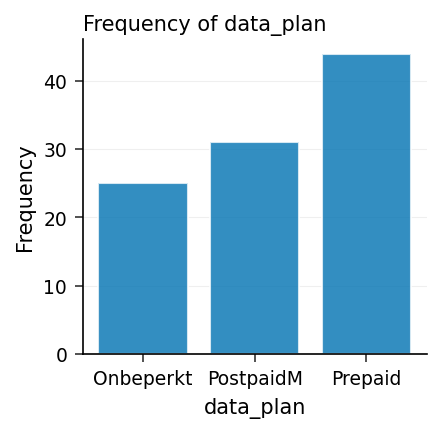

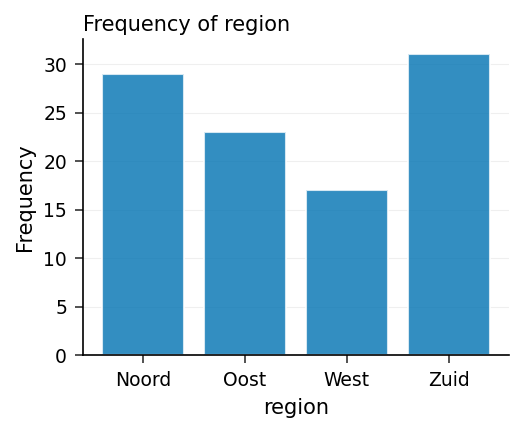

In [2]:
/* Samenvattende statistieken voor de clustervariabelen */
PROCEDURE GEMIDDELDEN GEGEVENS=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    label subscriber_id   = "Abonnee-ID"
          tenure_months   = "Klantduur (maanden)"
          monthly_data_gb = "Maandelijks dataverbruik (GB)"
          voice_minutes   = "Spraakminuten"
          sms_count       = "Aantal sms-berichten"
          intl_minutes    = "Internationale minuten"
          arpu            = "ARPU ($)"
          support_calls   = "Aantal supportgesprekken";
    VARIABELE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
UITVOEREN;

/* Frequentie van de twee categorische invoervariabelen */
PROCEDURE FREQUENTIES GEGEVENS=subscribers;
    label data_plan = "Abonnementstype"
          region     = "Regio";
    TABLES data_plan region / nocum;
UITVOEREN;

## 3. Standaardiseer de kenmerken naar z-scores

`PROC FASTCLUS` minimaliseert de Euclidische afstand, dus een variabele gemeten in honderden minuten zou een variabele overheersen die gemeten wordt in enkele gigabytes. `PROC STDIZE` met `METHOD=STD` herschaalt elk intervalkenmerk naar gemiddelde 0 en standaarddeviatie 1, zodat elk gedragskenmerk gelijk weegt in de afstand. De categorische kolommen en de identifier gaan ongewijzigd mee zodat we de clusters achteraf op hun oorspronkelijke schaal kunnen profileren.

In [3]:
/* z-score de intervalkenmerken; id's en categorische velden blijven ongewijzigd */
PROCEDURE stdize GEGEVENS=subscribers out=subs_std METHOD=std;
    VARIABELE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
UITVOEREN;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Fit de k-means-segmentatie

We fitten drie segmenten met `PROC FASTCLUS`. `MAXCLUSTERS=3` stelt *k* in; `MAXITER=20` laat de clustercentra itereren tot convergentie. De procedure rapporteert een **Clusteroverzicht** (grootte en RMS-afwijking binnen elk cluster), **Statistieken voor variabelen** (de R-kwadraat waarmee elk kenmerk bijdraagt), een **totale R-kwadraat** en **pseudo-F** die meten hoe zuiver de drie clusters scheiden, en **Clustergemiddelden** op de gestandaardiseerde schaal. `OUT=scored` schrijft de invoerrijen terug met een `CLUSTER`-label en de `DISTANCE` van elke abonnee tot zijn clusterzaad.

In [4]:
/* k-means-fit op de gestandaardiseerde kenmerken: 3 segmenten. */
PROCEDURE FASTCLUS GEGEVENS=subs_std maxclusters=3 MAXITER=20 out=scored;
    VARIABELE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
UITVOEREN;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Koppel segmentlabels aan de data op oorspronkelijke schaal

De gescoorde tabel bevat de gestandaardiseerde kenmerken; voor het profileren willen we de clusters beschreven in echte gigabytes, minuten en dollars. We voegen het `CLUSTER`-label terug samen met de oorspronkelijke `subscribers`-tabel op `subscriber_id`, en stellen dan de eerste vraag die marketing altijd stelt: *hoe groot is elk segment?*

                                                   The FREQ Procedure

Cluster    Frequency    Percent
--------------------------------
1                 36     36.00
2                 34     34.00
3                 30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


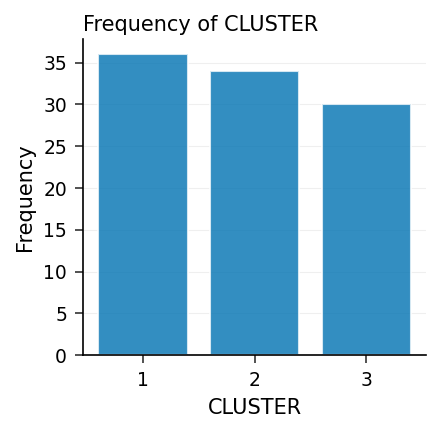

In [5]:
/* draag het clusterlabel terug naar de data op oorspronkelijke schaal */
PROCEDURE SORTEREN GEGEVENS=scored(keep=subscriber_id CLUSTER distance) out=clus_assign;
    VOLGENS subscriber_id;
UITVOEREN;
PROCEDURE SORTEREN GEGEVENS=subscribers out=subs_sorted;
    VOLGENS subscriber_id;
UITVOEREN;
GEGEVENS profile;
    SAMENVOEGEN subs_sorted clus_assign;
    VOLGENS subscriber_id;
UITVOEREN;

/* Hoeveel abonnees kwamen in elk segment terecht? */
PROCEDURE FREQUENTIES GEGEVENS=profile;
    label CLUSTER = "Cluster";
    TABLES CLUSTER / nocum;
UITVOEREN;

## 6. Profileer de segmenten

Cluster-ID's zijn betekenisloos totdat we het *gedrag* binnen elk ervan beschrijven. Het middelen van de oorspronkelijke (niet-gestandaardiseerde) kenmerken per `CLUSTER` onthult de persona achter elk segment -- wie streamt, wie belt, wie gebruikt het netwerk nauwelijks -- en de categorische mix laat zien welke abonnementen en regio's zich concentreren in elk segment.

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Klantduur (maanden)

        Cluster           N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                           Analysis Variable : monthly_data_gb Maandelijks dataverbruik (GB)

        Cluster           N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                    Analysis Variable : voice_minutes Spraakminuten

        Cluster           N Obs           Mean
        --------------------------------------
  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


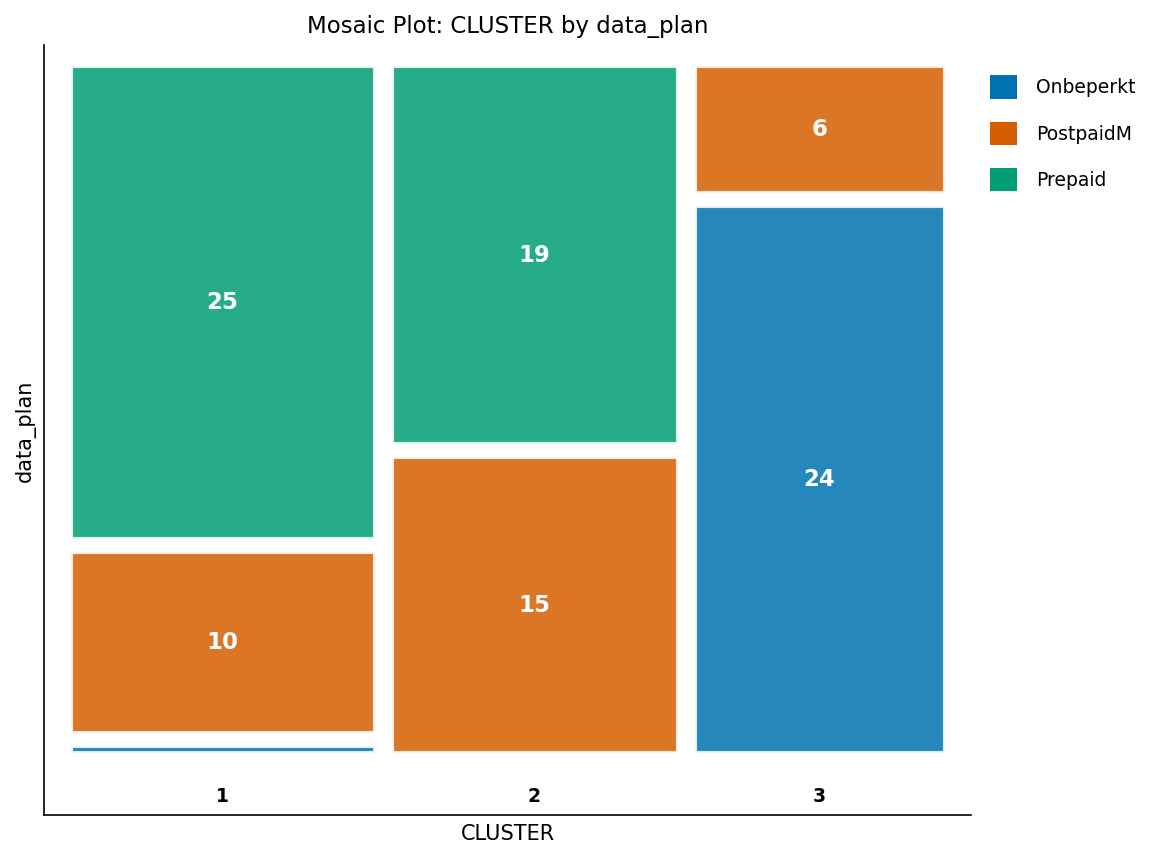

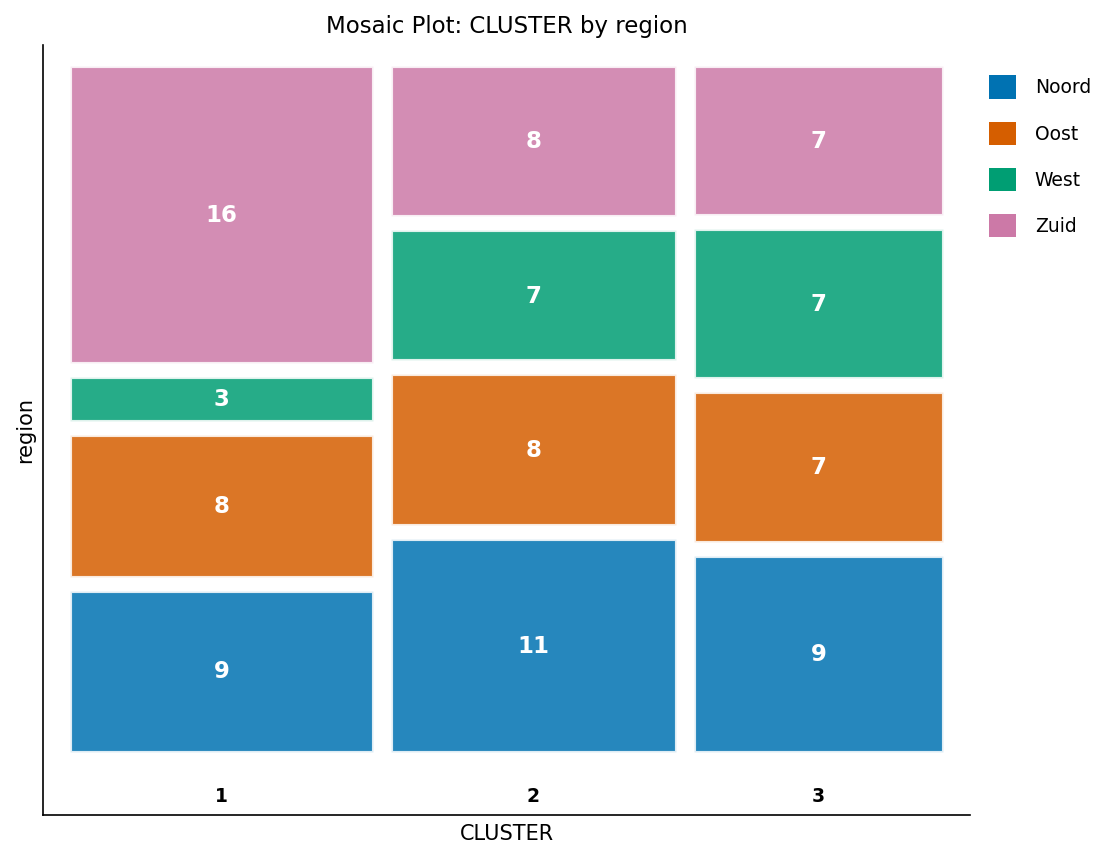

In [6]:
/* Gedragsprofiel: gemiddelde van elk kenmerk per segment */
PROCEDURE GEMIDDELDEN GEGEVENS=profile n mean maxdec=1;
    KLASSE CLUSTER;
    label CLUSTER          = "Cluster"
          tenure_months     = "Klantduur (maanden)"
          monthly_data_gb   = "Maandelijks dataverbruik (GB)"
          voice_minutes     = "Spraakminuten"
          sms_count         = "Aantal sms-berichten"
          intl_minutes      = "Internationale minuten"
          arpu              = "ARPU ($)"
          support_calls     = "Aantal supportgesprekken";
    VARIABELE tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
UITVOEREN;

/* Categorische mix binnen elk segment */
PROCEDURE FREQUENTIES GEGEVENS=profile;
    label CLUSTER   = "Cluster"
          data_plan = "Abonnementstype"
          region    = "Regio";
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
UITVOEREN;

## 7. Visualiseer de segmenten

Een afbeelding maakt de segmentatie tastbaar. We plotten datahonger tegenover spraakgebruik, gekleurd per segment, en voegen een boxplot van ARPU per segment toe zodat het omzetverhaal in één oogopslag duidelijk is.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


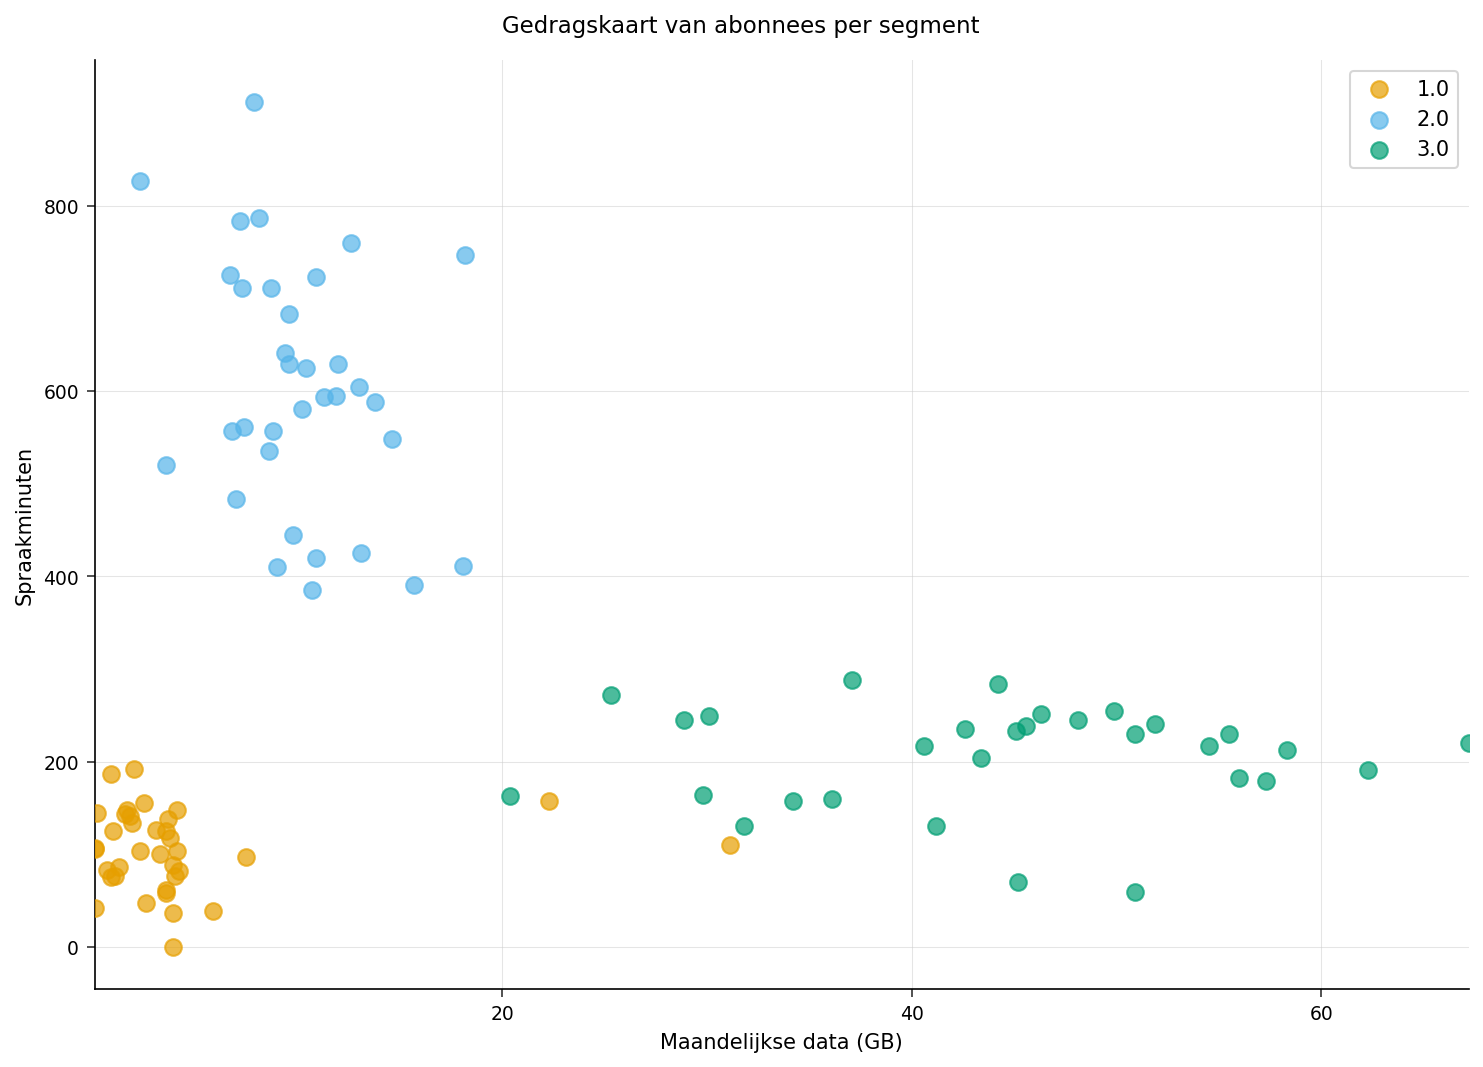

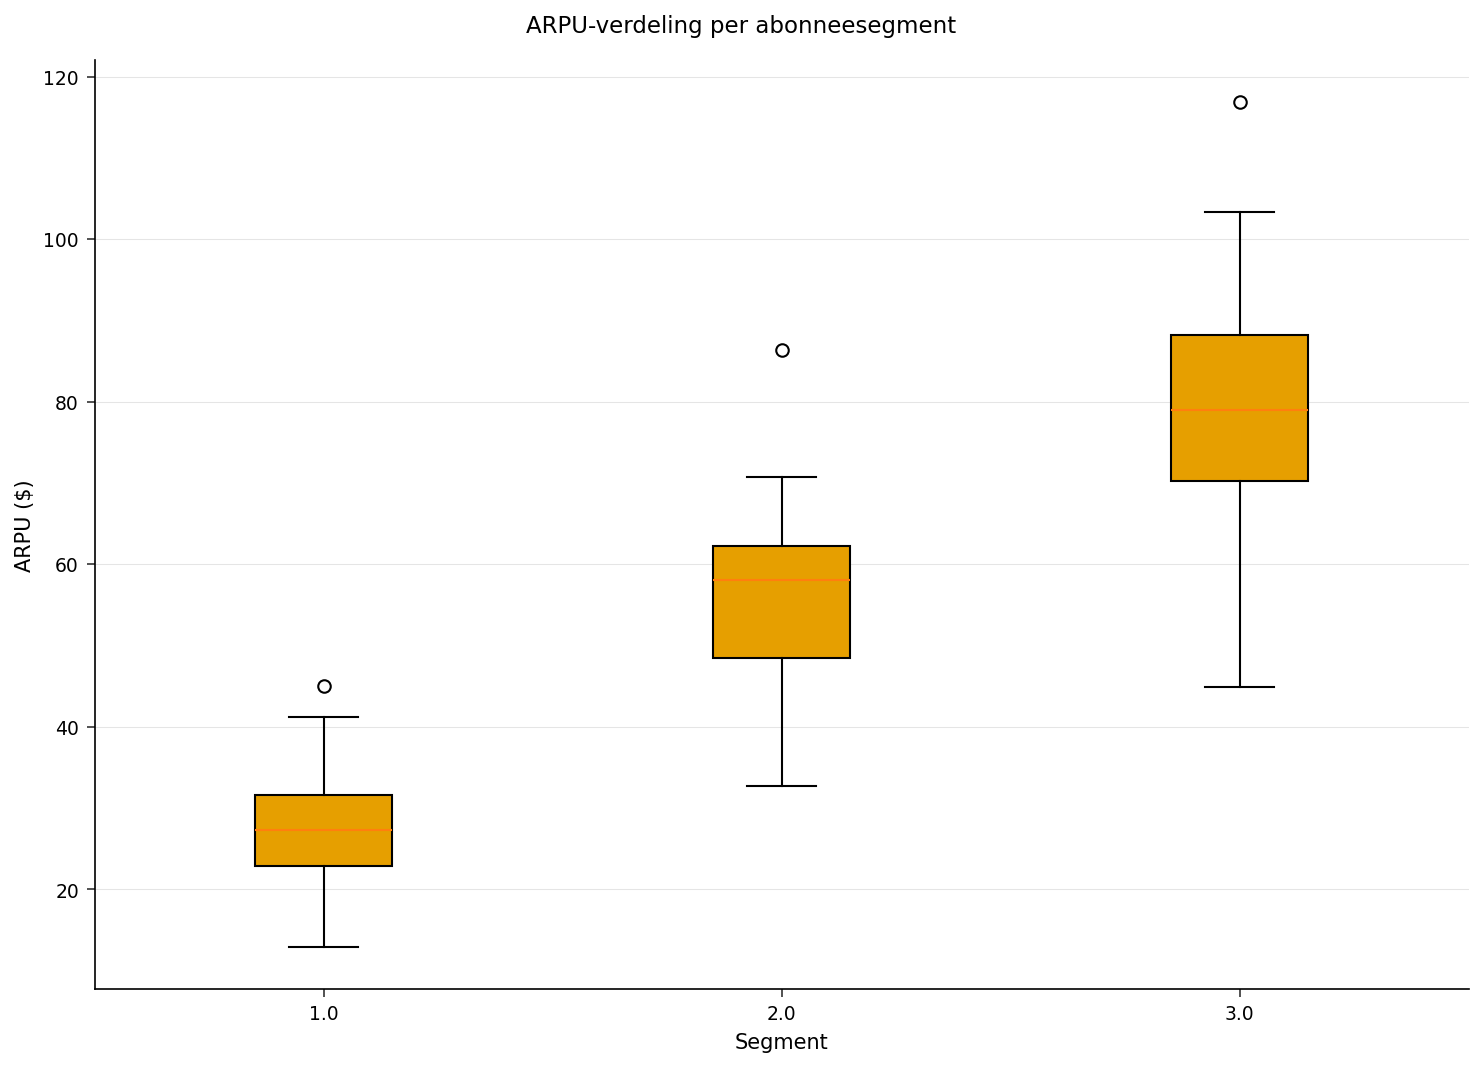

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Gedragskaart: data versus spraak, gekleurd per segment */
PROCEDURE SGPLOT GEGEVENS=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS label="Maandelijkse data (GB)" grid;
    YAXIS label="Spraakminuten"          grid;
    TITEL "Gedragskaart van abonnees per segment";
UITVOEREN;

/* Omzetverdeling per segment */
PROCEDURE SGPLOT GEGEVENS=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS label="Segment";
    YAXIS label="ARPU ($)" grid;
    TITEL "ARPU-verdeling per abonneesegment";
UITVOEREN;

## 8. Exporteer de gescoorde segmenten

Ten slotte dragen we de toewijzingen over aan downstream CRM- en campagnesystemen. We behouden de identifier, het clusterlabel en de belangrijkste gedragsvelden.

In [8]:
/* Bewaar de segmenttoewijzingen voor activatie */
GEGEVENS subscriber_segments;
    INSTELLEN profile;
    BEWAREN subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=subscriber_segments(obs=10) noobs label;
    label subscriber_id   = "Abonnee-ID"
          CLUSTER         = "Cluster"
          tenure_months   = "Klantduur (maanden)"
          monthly_data_gb = "Maandelijks dataverbruik (GB)"
          voice_minutes   = "Spraakminuten"
          arpu            = "ARPU ($)"
          data_plan       = "Abonnementstype"
          region          = "Regio";
    TITEL "Steekproef van gescoorde abonneesegmenten";
UITVOEREN;

                                       Steekproef van gescoorde abonneesegmenten                                        

Abonnee-ID  Cluster  Klantduur (maanden)  Maandelijks dataverbruik (GB)  Spraakminuten  ARPU ($)  Abonnementstype  Regio
    100001        1                   30                            2.3            104        28  Prepaid          Zuid
    100002        2                    8                           10.2            581     57.78  Prepaid          West
    100003        2                    8                           10.7            385     55.66  PostpaidM        Noord
    100004        2                   68                            7.4            561     70.68  Prepaid          Noord
    100005        3                   18                           45.6            239     63.85  Onbeperkt        Noord
    100006        3                   10                           30.1            249     88.33  Onbeperkt        Oost
    100007        1               


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interpretatie van de resultaten

`PROC FASTCLUS` vond drie duidelijke, goed gescheiden segmenten. De fit is solide: de **totale R-kwadraat is 0.575** en de **pseudo-F is 65.75**, wat betekent dat de drie clusters ongeveer 58% van de totale variatie in de gestandaardiseerde kenmerken verklaren. De scheiding wordt vrijwel volledig gedreven door de gedragssignalen waar het om gaat -- `voice_minutes` (R-kwadraat 0.858), `monthly_data_gb` (0.844) en `arpu` (0.771) dragen de segmentatie, terwijl `tenure_months` (0.000) en `support_calls` (0.193) vrijwel niets bijdragen, wat bevestigt dat *hoe* een abonnee het netwerk gebruikt -- niet hoe lang iemand al klant is -- de persona's bepaalt.

De drie segmenten sluiten direct aan op marketingklare persona's, hier geprofileerd op de oorspronkelijke (niet-gestandaardiseerde) schaal:

| Segment | n (aandeel) | Kenmerkend gedrag | Abonnementsmix | Persona | Aanbevolen actie |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Hoogste data: **44.4 GB/mnd**, hoogste uitgave **$79.1 ARPU**, bescheiden spraak (205 min) | 24/30 **Unlimited** | **Datastromers met veel gebruik** | Beschermen en upsellen: snellere tiers, contentbundels, toestelupgrades |
| **2** | 34 (34%) | Hoogste spraak **603 min/mnd**, **214 sms**, **106 int. min**, gemiddelde uitgave **$55.9 ARPU** | Prepaid + PostpaidM, **geen Unlimited** | **Spraakgerichte traditionalisten** | Internationale toevoegingen, gezins-/spraakbundels, loyaliteitsvoordelen |
| **1** | 36 (36%) | Laagste gebruik: **4.0 GB**, 104 spraakminuten, laagste uitgave **$28.0 ARPU** | 25/36 **Prepaid** | **Licht / weinig gebruik** | Abonnementen op maat, incasso-stimulansen, goedkope datastarters om gebruik te laten groeien |

De abonnementsmix bevestigt het gedragsbeeld: het segment met veel datagebruik zit overweldigend op **Unlimited**-abonnementen (24 van 30), het spraakgerichte segment heeft **geen** Unlimited-abonnees, en het segment met weinig gebruik zit vooral op **Prepaid** (25 van 36). Regio daarentegen is gelijkmatig verdeeld over alle drie segmenten -- geografie is hier geen gedragsdrijfveer, wat op zich een bruikbare bevinding is voor campagnetargeting.

**Waarom `PROC FASTCLUS` bij dit probleem past.** De procedure voert disjuncte k-means uit door over de data te lopen in plaats van een volledige afstandsmatrix te bouwen, zodat hetzelfde programma dat deze 100 abonnees segmenteerde, ook schaalt naar zeer grote bestanden. Het standaardiseren met `PROC STDIZE` verwijderde vooraf de schaalvertekening tussen gigabytes, minuten en dollars, zodat elk gedrag gelijk bijdroeg aan de Euclidische afstand; de R-kwadraat-diagnostiek liet vervolgens zien *welke* kenmerken de splitsing daadwerkelijk stuurden. De gescoorde uitvoer -- een `CLUSTER`-label voor elke abonnee -- gaat direct de activatiepijplijnen in en sluit zo de cirkel van ruw gedrag naar gerichte aanbieding.

---

<div style="font-size:11px;color:#9e9e9e">Deze notebook is uitsluitend bedoeld ter demonstratie. De data zijn synthetisch en de bevindingen vormen geen zakelijk advies.</div>
